In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.17.0
GPU: []


In [2]:
path = "tomato"

In [3]:
print("Files and folders inside dataset:")

for item in os.listdir(path):
    print(item)

Files and folders inside dataset:
Bacterial_spot
Early_blight
Healthy
Late_blight
Leaf_Mold
Mosaic_virus
Septoria_leaf_spot
Spider_mites Two-spotted_spider_mite
Target_Spot
Yellow_Leaf_Curl_Virus


In [4]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

tomato/
  Bacterial_spot/
  Early_blight/
  Healthy/
  Late_blight/
  Leaf_Mold/
  Mosaic_virus/
  Septoria_leaf_spot/
  Spider_mites Two-spotted_spider_mite/
  Target_Spot/
  Yellow_Leaf_Curl_Virus/


In [5]:
dataset_dir = path

print("Dataset directory:", dataset_dir)
print("\nClasses:")

for folder in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder)

    if os.path.isdir(folder_path):
        print(folder)

Dataset directory: tomato

Classes:
Bacterial_spot
Early_blight
Healthy
Late_blight
Leaf_Mold
Mosaic_virus
Septoria_leaf_spot
Spider_mites Two-spotted_spider_mite
Target_Spot
Yellow_Leaf_Curl_Virus


In [6]:
classes = []

for folder in os.listdir(dataset_dir):

    folder_path = os.path.join(dataset_dir, folder)

    if os.path.isdir(folder_path):
        classes.append(folder)

print("Number of classes:", len(classes))

for class_name in classes:

    class_path = os.path.join(dataset_dir, class_name)

    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"{class_name}: {image_count} images")

Number of classes: 10
Bacterial_spot: 2127 images
Early_blight: 1000 images
Healthy: 1591 images
Late_blight: 1909 images
Leaf_Mold: 952 images
Mosaic_virus: 373 images
Septoria_leaf_spot: 1771 images
Spider_mites Two-spotted_spider_mite: 1676 images
Target_Spot: 1404 images
Yellow_Leaf_Curl_Virus: 5357 images


In [7]:
from pathlib import Path
from sklearn.model_selection import train_test_split

dataset_path = Path("tomato")

image_height = 224
image_width = 224
batch_size = 32
seed = 42

# Build a stratified train/validation split so every class is
# proportionally represented in both sets (fixes skewed splits
# caused by class imbalance + alphabetical file ordering).
class_names = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
class_to_idx = {name: i for i, name in enumerate(class_names)}

all_paths, all_labels = [], []
for class_name in class_names:
    for f in (dataset_path / class_name).iterdir():
        if f.suffix.lower() in (".jpg", ".jpeg", ".png"):
            all_paths.append(str(f))
            all_labels.append(class_to_idx[class_name])

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    random_state=seed,
    stratify=all_labels
)

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (image_height, image_width))
    return img, label

train_dataset = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000, seed=seed)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

validation_dataset = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

print("Number of classes:", len(class_names))
print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))

Number of classes: 10
Training images: 14528
Validation images: 3632


In [8]:
print("Classes:")
for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

print("Number of classes:", len(class_names))

Classes:
0 : Bacterial_spot
1 : Early_blight
2 : Healthy
3 : Late_blight
4 : Leaf_Mold
5 : Mosaic_virus
6 : Septoria_leaf_spot
7 : Spider_mites Two-spotted_spider_mite
8 : Target_Spot
9 : Yellow_Leaf_Curl_Virus
Number of classes: 10


In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [10]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    
    tf.keras.layers.Input(
        shape=(image_height, image_width, 3)
    ),

    # Data augmentation
    data_augmentation,

    # Normalize pixels
    normalization_layer,

    # CNN Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    # CNN Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    # CNN Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    # CNN Block 4
    tf.keras.layers.Conv2D(
        256,
        (3, 3),
        activation="relu"
    ),
    tf.keras.layers.MaxPooling2D(),

    # Classification
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation="softmax"
    )
])

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,778 (1.74 MB)

 Trainable params: 456,778 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Compute class weights to handle any class imbalance

train_labels = np.concatenate([y.numpy() for x, y in train_dataset.unbatch().batch(1024)])

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(zip(np.unique(train_labels), class_weight_values))

print("Class weights:")
for class_idx, weight in class_weight_dict.items():
    print(f"{class_names[class_idx]}: {weight:.3f}")

Class weights:
Bacterial_spot: 0.854
Early_blight: 1.816
Healthy: 1.141
Late_blight: 0.951
Leaf_Mold: 1.909
Mosaic_virus: 4.875
Septoria_leaf_spot: 1.025
Spider_mites Two-spotted_spider_mite: 1.083
Target_Spot: 1.294
Yellow_Leaf_Curl_Virus: 0.339


In [14]:
# Callbacks: stop early on plateau, keep the best weights on disk

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_tomato_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [15]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping, checkpoint],
    class_weight=class_weight_dict
)

Epoch 1/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 139s 302ms/step - accuracy: 0.3586 - loss: 1.9565 - val_accuracy: 0.4725 - val_loss: 1.3980
Epoch 2/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 138s 304ms/step - accuracy: 0.6004 - loss: 1.2333 - val_accuracy: 0.7084 - val_loss: 0.7929
Epoch 3/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 139s 306ms/step - accuracy: 0.7256 - loss: 0.8248 - val_accuracy: 0.5884 - val_loss: 1.2712
Epoch 4/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 139s 306ms/step - accuracy: 0.7858 - loss: 0.6441 - val_accuracy: 0.6787 - val_loss: 1.1512
Epoch 5/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 139s 306ms/step - accuracy: 0.8212 - loss: 0.5395 - val_accuracy: 0.8444 - val_loss: 0.4474
Epoch 6/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 140s 307ms/step - accuracy: 0.8382 - loss: 0.4922 - val_accuracy: 0.8585 - val_loss: 0.3755
Epoch 7/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 139s 306ms/step - accuracy: 0.8570 - loss: 0.4452 - val_accuracy: 0.8351 - val_loss: 0.5479
Epoch 8/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 140s 307ms/step - accuracy: 0.8766 -

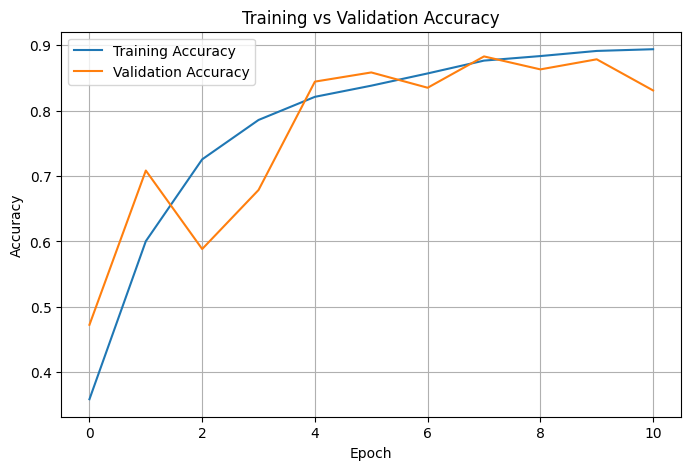

In [16]:

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

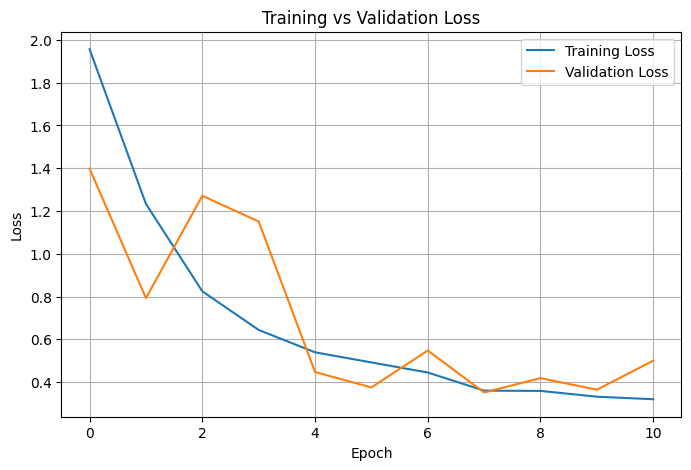

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [18]:
# Evaluate model on validation dataset

val_loss, val_accuracy = model.evaluate(validation_dataset)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

114/114 ━━━━━━━━━━━━━━━━━━━━ 19s 168ms/step - accuracy: 0.8830 - loss: 0.3517
Validation Loss: 0.3517
Validation Accuracy: 88.30%


In [19]:
# Save the final model

model.save("tomato_disease_final_model.keras")
print("Model saved to tomato_disease_final_model.keras")

Model saved to tomato_disease_final_model.keras


In [20]:
# Generate predictions for the validation dataset
# (validation_dataset is already a clean, stratified, non-shuffled split)

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    
    predicted_classes = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")
print("Number of validation images:", len(y_true))
print("Unique labels in y_true:", np.unique(y_true))

Predictions generated successfully.
Number of validation images: 3632
Unique labels in y_true: [0 1 2 3 4 5 6 7 8 9]


In [21]:
print("Unique labels in y_true:", np.unique(y_true))
print("Unique labels in y_pred:", np.unique(y_pred))

print("\nClass distribution in y_true:")

for label, count in zip(*np.unique(y_true, return_counts=True)):
    print(f"{label}: {class_names[label]} -> {count}")

Unique labels in y_true: [0 1 2 3 4 5 6 7 8 9]
Unique labels in y_pred: [0 1 2 3 4 5 6 7 8 9]

Class distribution in y_true:
0: Bacterial_spot -> 425
1: Early_blight -> 200
2: Healthy -> 318
3: Late_blight -> 382
4: Leaf_Mold -> 191
5: Mosaic_virus -> 75
6: Septoria_leaf_spot -> 354
7: Spider_mites Two-spotted_spider_mite -> 335
8: Target_Spot -> 281
9: Yellow_Leaf_Curl_Virus -> 1071


In [22]:
print("Class names:")
for i, name in enumerate(class_names):
    print(i, name)

Class names:
0 Bacterial_spot
1 Early_blight
2 Healthy
3 Late_blight
4 Leaf_Mold
5 Mosaic_virus
6 Septoria_leaf_spot
7 Spider_mites Two-spotted_spider_mite
8 Target_Spot
9 Yellow_Leaf_Curl_Virus


In [23]:
print("Validation batches:", len(validation_dataset))
print("Validation images:", len(y_true))

Validation batches: 114
Validation images: 3632


In [24]:
print("Classification Report:\n")

unique_labels = np.unique(y_true)
target_names = [class_names[i] for i in unique_labels]

print(
    classification_report(
        y_true,
        y_pred,
        labels=unique_labels,
        target_names=target_names,
        digits=4
    )
)

Classification Report:

                                      precision    recall  f1-score   support

                      Bacterial_spot     0.9104    0.9082    0.9093       425
                        Early_blight     0.7317    0.7500    0.7407       200
                             Healthy     0.8689    1.0000    0.9298       318
                         Late_blight     0.7832    0.9267    0.8489       382
                           Leaf_Mold     0.9010    0.9058    0.9034       191
                        Mosaic_virus     0.8043    0.9867    0.8862        75
                  Septoria_leaf_spot     0.9805    0.7119    0.8249       354
Spider_mites Two-spotted_spider_mite     0.8454    0.8000    0.8221       335
                         Target_Spot     0.7568    0.8861    0.8164       281
              Yellow_Leaf_Curl_Virus     0.9850    0.9178    0.9502      1071

                            accuracy                         0.8830      3632
                           macro avg  

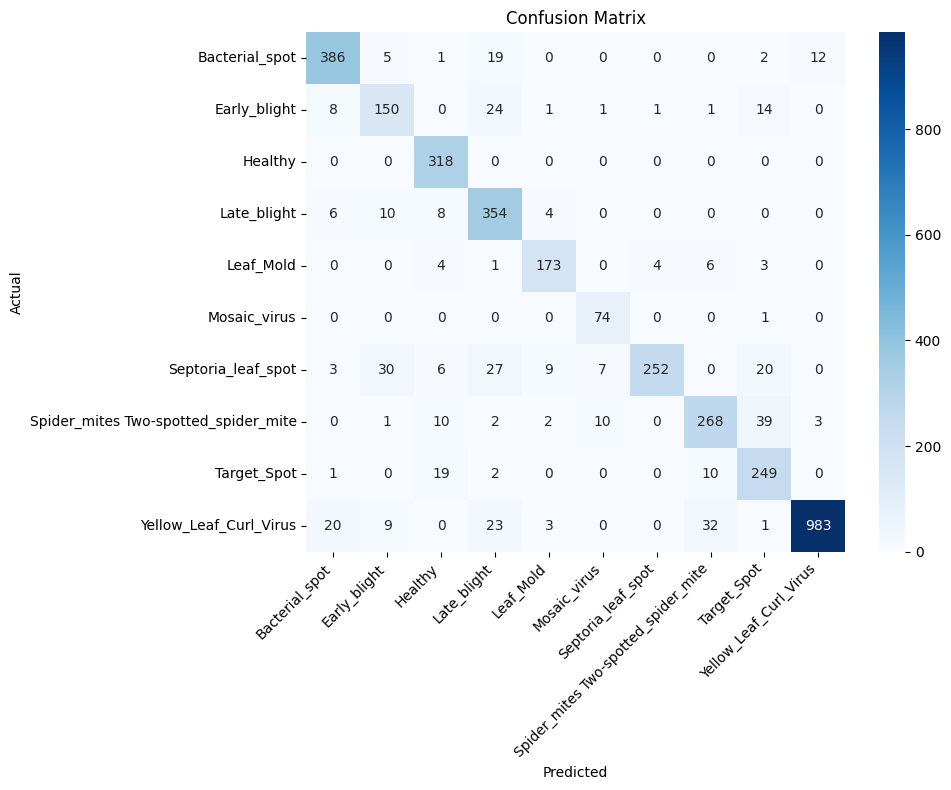

In [25]:
# Confusion matrix

cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
def predict_single_image(img_path, model, class_names, img_size=(224, 224)):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.show()

    return predicted_class, confidence

# Example usage (replace with an actual image path):
# predict_single_image("tomato/Tomato___Early_blight/example.jpg", model, class_names)